In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.

['retina', 'benchmark-dataset']


In [2]:
import numpy as np
import pickle
import cv2
from os import listdir
from sklearn.preprocessing import LabelBinarizer
from keras.models import Sequential
from keras.layers.normalization import BatchNormalization
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras.layers.core import Activation, Flatten, Dropout, Dense
from keras import backend as K
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam
from keras.preprocessing import image
from keras.preprocessing.image import img_to_array
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [14]:
EPOCHS = 10
INIT_LR = 1e-3
BS = 32
default_image_size = tuple((224, 224))
image_size = 0
directory_root = '../input/retina/'
width=224
height=224
depth=3

In [4]:
def convert_image_to_array(image_dir):
    try:
        image = cv2.imread(image_dir)
        if image is not None :
            image = cv2.resize(image, default_image_size)   
            return img_to_array(image)
        else :
            return np.array([])
    except Exception as e:
        print(f"Error : {e}")
        return None

In [5]:
image_list, label_list = [], []
try:
    print("[INFO] Loading images ...")
    root_dir = listdir(directory_root)
    for directory in root_dir :
        # remove .DS_Store from list
        if directory == ".DS_Store" :
            root_dir.remove(directory)

    for plant_folder in root_dir :
        plant_disease_folder_list = listdir(f"{directory_root}/{plant_folder}")
        
        for disease_folder in plant_disease_folder_list :
            # remove .DS_Store from list
            if disease_folder == ".DS_Store" :
                plant_disease_folder_list.remove(disease_folder)

        for plant_disease_folder in plant_disease_folder_list:
            print(f"[INFO] Processing {plant_disease_folder} ...")
            plant_disease_image_list = listdir(f"{directory_root}/{plant_folder}/{plant_disease_folder}/")
                
            for single_plant_disease_image in plant_disease_image_list :
                if single_plant_disease_image == ".DS_Store" :
                    plant_disease_image_list.remove(single_plant_disease_image)
            for image in plant_disease_image_list[:500]:
                image_directory = f"{directory_root}/{plant_folder}/{plant_disease_folder}/{image}"
                if image_directory.endswith(".png") == True or image_directory.endswith(".PNG") == True:
                    image_list.append(convert_image_to_array(image_directory))
                    label_list.append(plant_disease_folder)
    print("[INFO] Image loading completed")  
except Exception as e:
    print(f"Error : {e}")

[INFO] Loading images ...
[INFO] Processing Mild ...
[INFO] Processing Proliferate_DR ...
[INFO] Processing Moderate ...
[INFO] Processing No_DR ...
[INFO] Processing Severe ...
[INFO] Image loading completed


In [6]:
image_size = len(image_list)
image_size

1858

In [7]:
label_binarizer = LabelBinarizer()
image_labels = label_binarizer.fit_transform(label_list)
pickle.dump(label_binarizer,open('label_transform.pkl', 'wb'))
n_classes = len(label_binarizer.classes_)

In [8]:
print(label_binarizer.classes_)

['Mild' 'Moderate' 'No_DR' 'Proliferate_DR' 'Severe']


In [9]:
np_image_list = np.array(image_list, dtype=np.float16) 

In [10]:
#First to split to train, test and then split train again into validation and train. Something like this 
x_train, x_test, y_train, y_test  = train_test_split(np_image_list, image_labels,test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=42)

In [11]:
aug = ImageDataGenerator(
    rotation_range=25, width_shift_range=0.1,
    height_shift_range=0.1, shear_range=0.2, 
    zoom_range=0.2,horizontal_flip=True, 
    fill_mode="nearest")


In [12]:
model = Sequential()
inputShape = (height, width, depth)
chanDim = -1
if K.image_data_format() == "channels_first":
    inputShape = (depth, height, width)
    chanDim = 1
model.add(Conv2D(32, (3, 3), padding="same",input_shape=inputShape))
model.add(Activation("relu"))
model.add(BatchNormalization(axis=chanDim))
model.add(MaxPooling2D(pool_size=(3, 3)))


model.add(Conv2D(64, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(BatchNormalization(axis=chanDim))
model.add(MaxPooling2D(pool_size=(3, 3)))

model.add(Conv2D(64, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(BatchNormalization(axis=chanDim))

model.add(Conv2D(164, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(BatchNormalization(axis=chanDim))

model.add(Conv2D(164, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(BatchNormalization(axis=chanDim))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(4096))
model.add(Activation("relu"))
model.add(Dense(1024))
model.add(Activation("relu"))
model.add(Dense(n_classes))
model.add(Activation("softmax"))

In [ ]:
model.summary()

In [15]:
opt = Adam(lr=INIT_LR, decay=INIT_LR / EPOCHS)
# distribution
model.compile(loss="categorical_crossentropy", optimizer=opt,metrics=["accuracy"])
# train the network
print("[INFO] training network...")

[INFO] training network...


In [16]:

history = model.fit_generator(
    aug.flow(x_train, y_train, batch_size=BS),
    validation_data=(x_val, y_val),
    steps_per_epoch=len(x_train) // BS,
    epochs=EPOCHS, verbose=1
    )

/opt/conda/lib/python3.7/site-packages/tensorflow/python/keras/engine/training.py:1844: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


Epoch 1/10
34/34 [==============================] - 18s 381ms/step - loss: 26.4056 - accuracy: 0.2659 - val_loss: 420.0753 - val_accuracy: 0.2984
Epoch 2/10
34/34 [==============================] - 12s 341ms/step - loss: 4.6376 - accuracy: 0.3672 - val_loss: 13.4552 - val_accuracy: 0.3038
Epoch 3/10
34/34 [==============================] - 12s 342ms/step - loss: 1.5788 - accuracy: 0.3908 - val_loss: 1.5794 - val_accuracy: 0.3898
Epoch 4/10
34/34 [==============================] - 12s 343ms/step - loss: 1.3459 - accuracy: 0.4681 - val_loss: 1.4675 - val_accuracy: 0.3844
Epoch 5/10
34/34 [==============================] - 12s 345ms/step - loss: 1.3316 - accuracy: 0.4578 - val_loss: 1.2960 - val_accuracy: 0.4839
Epoch 6/10
34/34 [==============================] - 12s 346ms/step - loss: 1.2476 - accuracy: 0.4993 - val_loss: 1.2728 - val_accuracy: 0.4946
Epoch 7/10
34/34 [==============================] - 12s 347ms/step - loss: 1.2480 - accuracy: 0.4919 - val_loss: 1.1345 - val_accuracy: 0.

In [21]:
print("[INFO] Calculating model accuracy")
loss, accuracy = model.evaluate(x_test, y_test)

print(loss,accuracy)

[INFO] Calculating model accuracy
12/12 [==============================] - 1s 92ms/step - loss: 1.2010 - accuracy: 0.5027
1.201028823852539 0.5026881694793701


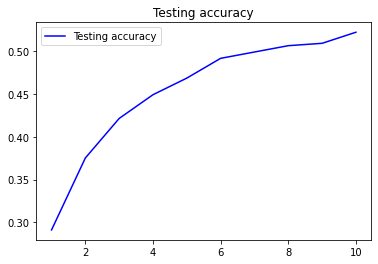

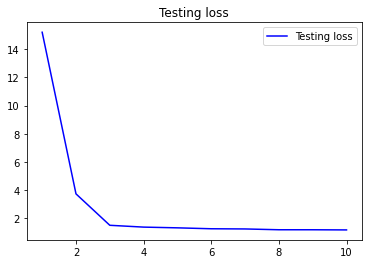

In [22]:
acc = history.history['accuracy']
loss = history.history['loss']
epochs = range(1, len(acc) + 1)
#Train and validation accuracy
plt.plot(epochs, acc, 'b', label='Testing accuracy')
plt.title('Testing accuracy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss, 'b', label='Testing loss')
plt.title('Testing loss')
plt.legend()
plt.show()

In [23]:
y_pred = model.predict(x_test)

#getting labels
y_pred_labels = np.argmax(y_pred,axis = 1)
y_true = np.argmax(y_test,axis = 1)

In [24]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve,auc

cm = confusion_matrix(y_true,y_pred_labels)
cm = cm.astype(np.float) / cm.sum(axis=1)[:, np.newaxis]

In [26]:
import pandas as pd
import seaborn as sns
from itertools import cycle

from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support

In [27]:
#Transform to df for easier plotting
cm_df = pd.DataFrame(cm, index = label_binarizer.classes_,
                     columns = label_binarizer.classes_
                    )

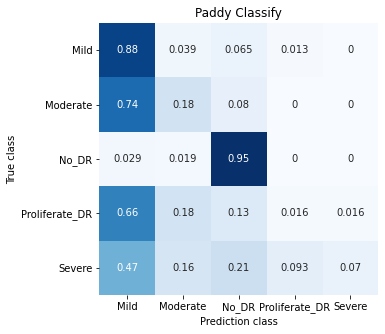

In [28]:
plt.figure(figsize = (5,5))
sns.heatmap(cm_df, annot = True,cmap='Blues',cbar=False)
plt.title('Paddy Classify')
plt.ylabel('True class')
plt.xlabel('Prediction class')
plt.show()

In [29]:
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(classification_report(y_true,y_pred_labels))

              precision    recall  f1-score   support

           0       0.35      0.88      0.50        77
           1       0.41      0.18      0.25        87
           2       0.77      0.95      0.85       104
           3       0.17      0.02      0.03        61
           4       0.75      0.07      0.13        43

    accuracy                           0.50       372
   macro avg       0.49      0.42      0.35       372
weighted avg       0.50      0.50      0.42       372

